<h1>Pneumonia detection using Convolutional neural networks</h1>

The dataset used here is chest xray dataset which is preprocessed.
You can find the **Dataset** [here.](https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia)

In [ ]:
!pip install tensorflow

In [ ]:
pip install keras

The dataset consists of :


*   5216 training images of which 3815 are of Pneumonia and 1341 are normal images.
*   624 testing images of which 390 are of Pneumonia and 234 are normal.




In [ ]:
pip install opencv-python

In [ ]:
pip install imagepreprocessing

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image
from tensorflow.keras.optimizers import Adam
import cv2
from keras.preprocessing.image import img_to_array

The below mentioned google.colab import drive is used to import drive to colab and drive.mount is used to mount data which is present in drive, so that we can access it. 

**Training data.**

In [3]:
train_images = r"C:\Users\AMRIN MULLA\Downloads\chest xray dataset\chest_xray\train"

**Creating the train data generator.**

In [4]:
# Initialize ImageDataGenerator with any desired data augmentation or preprocessing parameters
train_datagen = ImageDataGenerator( 
    rescale=1./255,            # Rescale pixel values to be between 0 and 1
    shear_range=0.2,           # Shear angle for shear augmentation
    zoom_range=0.2,            # Zoom range for zoom augmentation
    horizontal_flip=True)   

Here every image is resized to (300,300)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_images,              # Directory containing training images
    target_size=(300, 300),    # Resize images to 300x300
    batch_size=128,            # Batch size
    class_mode='binary'        # Class mode (binary classification)
)

Found 5216 images belonging to 2 classes.


**Model outputs :**

0 : Normal condition

1 : Pneumonia condition

In [6]:
train_generator.class_indices

{'NORMAL': 0, 'PNEUMONIA': 1}

**Validation data generator and loading validation data**

In [7]:
test_datagen = ImageDataGenerator(rescale = 1./255)
validation_generator = test_datagen.flow_from_directory(r"C:\Users\AMRIN MULLA\Downloads\chest xray dataset\chest_xray\train",
    target_size= (300,300),
    batch_size = 128,
    class_mode = 'binary')

Found 5216 images belonging to 2 classes.


**Plotting :** Images with Pneumonia from dataset.

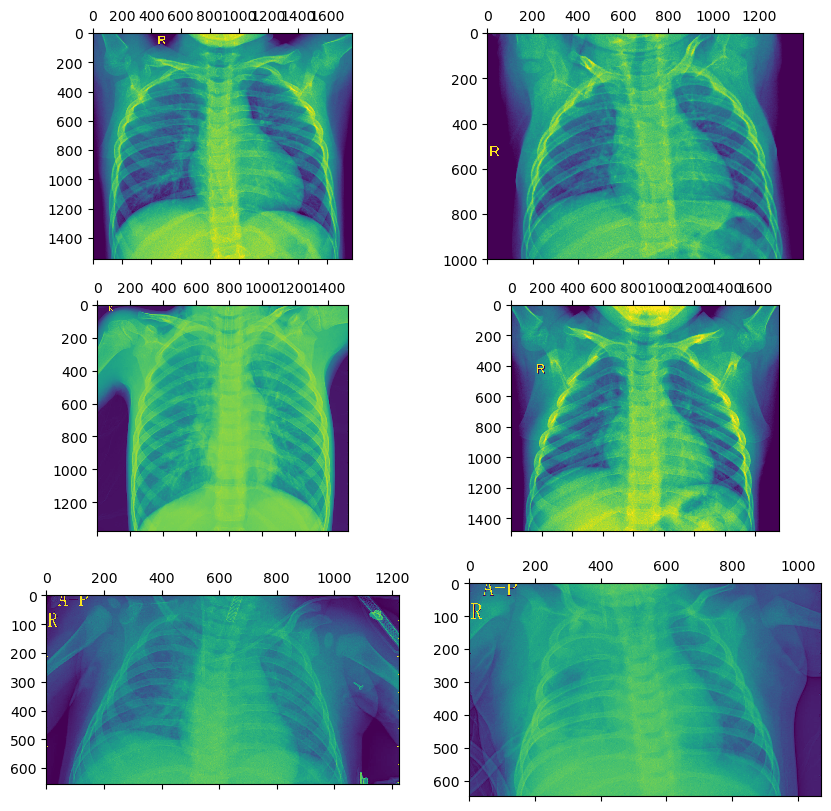

In [8]:
#Pneumonia
plot_image = plt.figure(figsize=(10,10))

plot1 = plot_image.add_subplot(3,2,1)
plot2 = plot_image.add_subplot(3,2,2)
plot3 = plot_image.add_subplot(3,2,3)
plot4 = plot_image.add_subplot(3,2,4)
plot5 = plot_image.add_subplot(3,2,5)
plot6 = plot_image.add_subplot(3,2,6)
plot1.matshow(plt.imread(train_generator.filepaths[41]))
plot2.matshow(plt.imread(train_generator.filepaths[176]))
plot3.matshow(plt.imread(train_generator.filepaths[1553]))
plot4.matshow(plt.imread(train_generator.filepaths[354]))
plot5.matshow(plt.imread(train_generator.filepaths[2679]))
plot6.matshow(plt.imread(train_generator.filepaths[2710]))

**Plotting :** Images without Pneumonia from dataset.

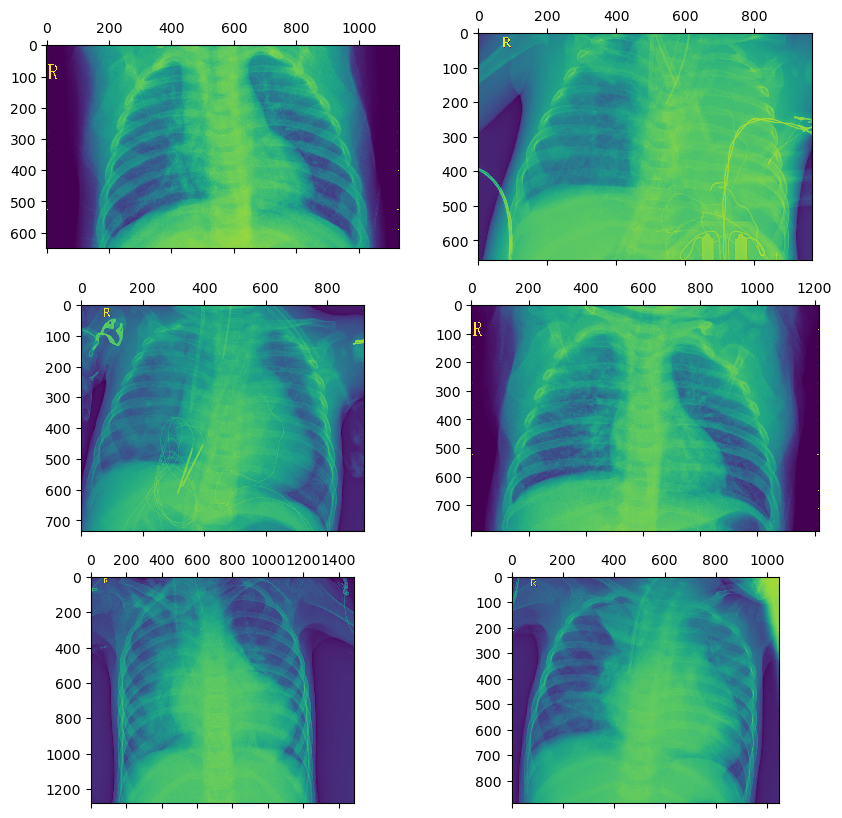

In [9]:
#Normal
plot_image = plt.figure(figsize=(10,10))

plot1 = plot_image.add_subplot(3,2,1)
plot2 = plot_image.add_subplot(3,2,2)
plot3 = plot_image.add_subplot(3,2,3)
plot4 = plot_image.add_subplot(3,2,4)
plot5 = plot_image.add_subplot(3,2,5)
plot6 = plot_image.add_subplot(3,2,6)
plot1.matshow(plt.imread(train_generator.filepaths[1419]))
plot2.matshow(plt.imread(train_generator.filepaths[1365]))
plot3.matshow(plt.imread(train_generator.filepaths[1400]))
plot4.matshow(plt.imread(train_generator.filepaths[1350]))
plot5.matshow(plt.imread(train_generator.filepaths[1345]))
plot6.matshow(plt.imread(train_generator.filepaths[1349]))

<h1>Neural Networks using TensorFlow</h1>

Metrics : Accuracy.

In [10]:
model= tf.keras.models.Sequential([
                                   tf.keras.layers.Conv2D(16, (3,3), activation= 'relu', input_shape= (300, 300, 3)),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(32, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(64, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(128, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   tf.keras.layers.Conv2D(128, (3,3), activation= 'relu'),
                                   tf.keras.layers.MaxPool2D(2,2),

                                   tf.keras.layers.Flatten(),
                                   tf.keras.layers.Dense(256, activation= 'relu'),
                                   tf.keras.layers.Dense(512, activation= 'relu'),
                                   tf.keras.layers.Dense(1, activation= 'sigmoid')
])
model.summary()
model.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics = ['accuracy','Precision','Recall',])

C:\Users\AMRIN MULLA\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 298, 298, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 149, 149, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 147, 147, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 73, 73, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 71, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 35, 35, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 33, 33, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,605,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,983,009 (7.56 MB)

 Trainable params: 1,983,009 (7.56 MB)

 Non-trainable params: 0 (0.00 B)

**Training the model for 50 epochs**

<h2>Accuracy : 98.16%</h2>

In [11]:
history = model.fit(train_generator, epochs = 1, validation_data = validation_generator)

41/41 ━━━━━━━━━━━━━━━━━━━━ 533s 13s/step - Precision: 0.7502 - Recall: 0.9587 - accuracy: 0.7322 - loss: 0.5847 - val_Precision: 0.7471 - val_Recall: 1.0000 - val_accuracy: 0.7485 - val_loss: 0.4497


In [13]:
loss = history.history['loss']
val_loss = history.history['val_loss']

**<h3>Plotting Loss Vs Num. of Epochs</h3>**

Loss Vs Num. of Epochs
Training Loss : 0.0519 
Value loss : 0.0701


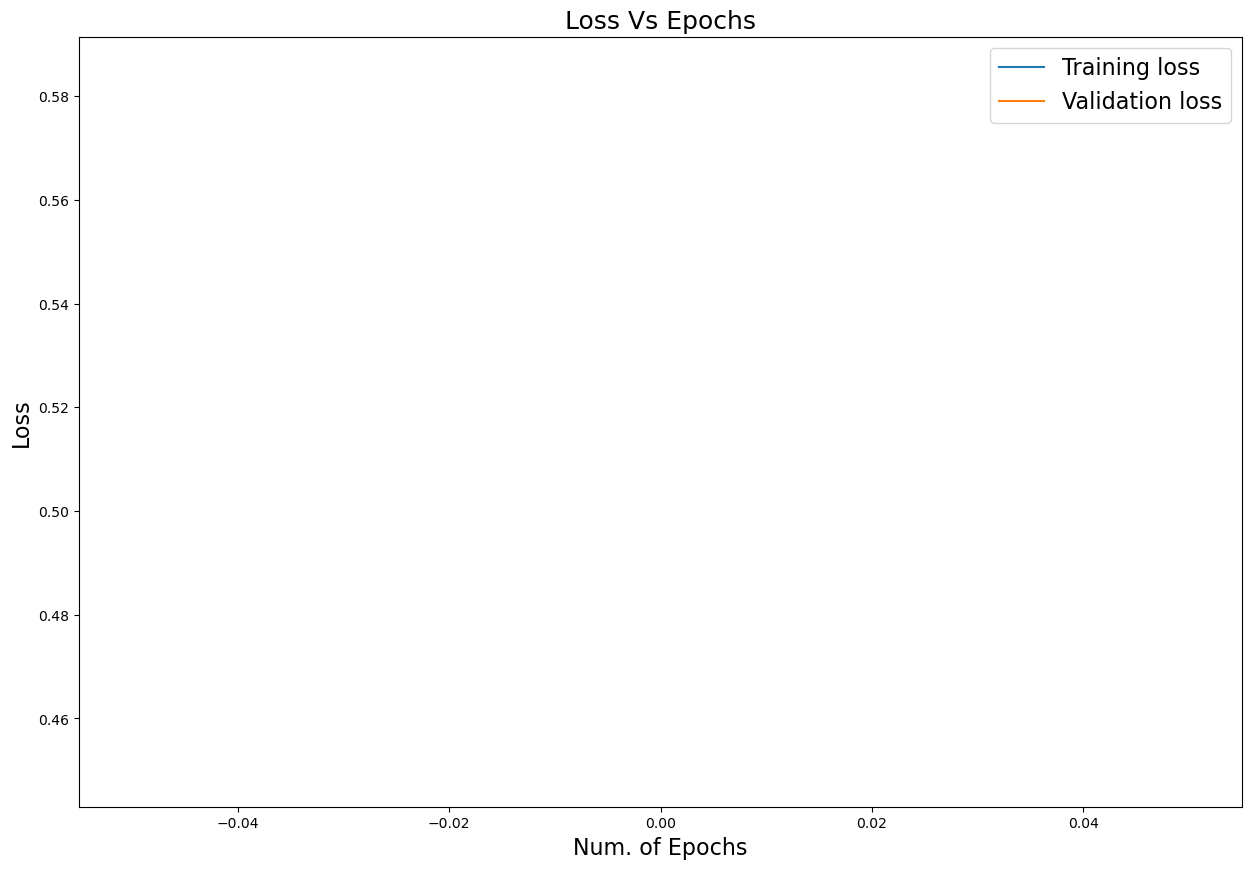

In [14]:
plt.figure(figsize=(15, 10))
plt.plot(loss)
plt.plot(val_loss)
plt.legend(['Training loss','Validation loss'], fontsize=16)
plt.title("Loss Vs Epochs", fontsize=18)
plt.xlabel("Num. of Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
print("Loss Vs Num. of Epochs")
print("Training Loss : 0.0519","\nValue loss : 0.0701")
plt.show()

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

**<h3>Plotting Accuracy Vs Num. of Epochs</h3>**

Accuracy Vs Epochs
Training accuracy : 0.9816 
Value accuracy : 1.0000


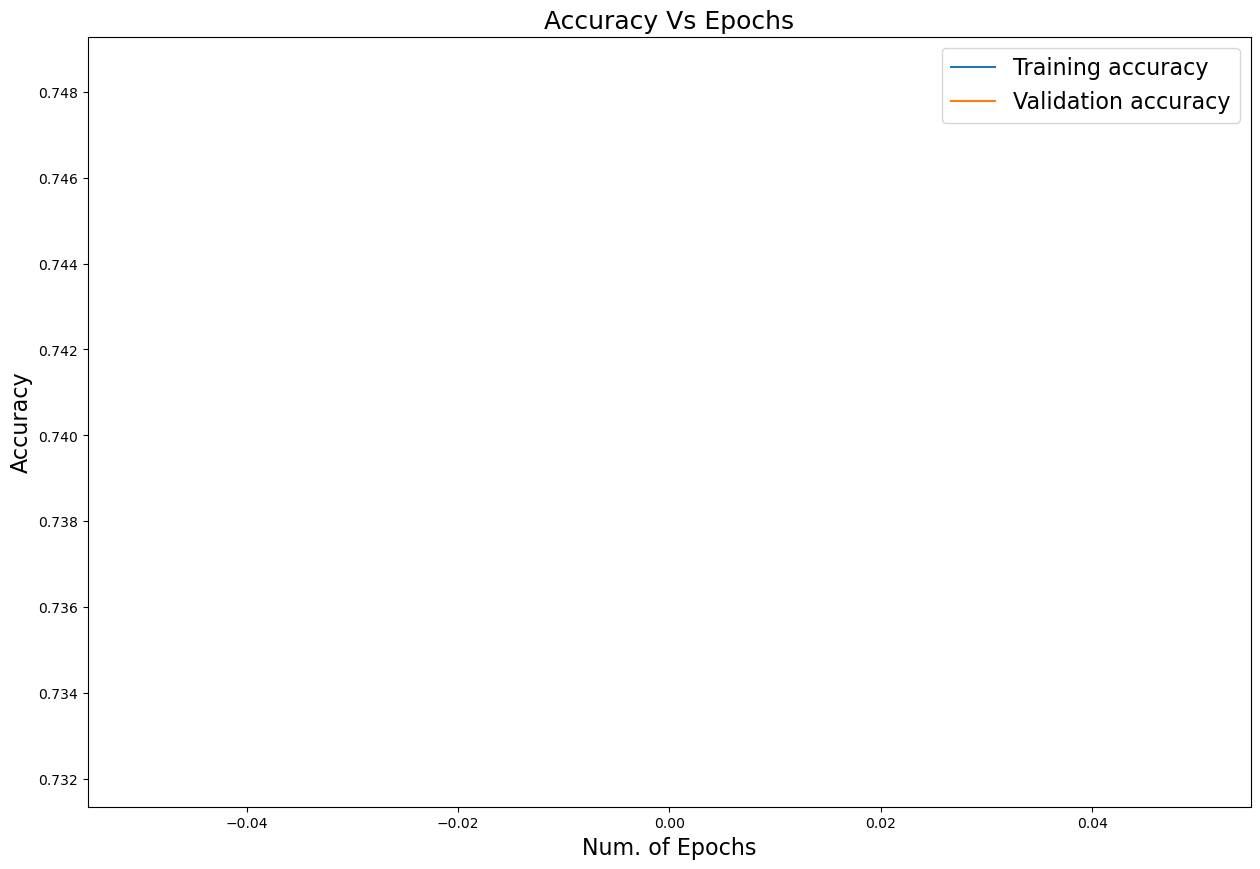

In [16]:
plt.figure(figsize=(15, 10))
plt.plot(acc)
plt.plot(val_acc)
plt.legend(['Training accuracy','Validation accuracy'], fontsize=16)
plt.title("Accuracy Vs Epochs", fontsize=18)
plt.xlabel("Num. of Epochs", fontsize=16)
plt.ylabel("Accuracy", fontsize=16)
print("Accuracy Vs Epochs")
print("Training accuracy : 0.9816","\nValue accuracy : 1.0000")
plt.show()

<h3>Saving the model</h3>

In [17]:
model.save("trained.h5")

<h3>Loading the saved model so that we can load the model which is already saved so lot of time can be saved and it can also be used for deployment.</h3>

In [18]:
from keras.models import load_model
model = load_model("trained.h5")

**Loading the test data generator from drive**

In [21]:
eval_datagen = ImageDataGenerator(rescale = 1/255)

test_generator = eval_datagen.flow_from_directory(
    r"C:\Users\AMRIN MULLA\Downloads\chest xray dataset\chest_xray\test",
    target_size = (300, 300),
    batch_size = 128, 
    class_mode = 'binary'
)

eval_result = model.evaluate(test_generator, steps=624)

print('loss :', eval_result[0])
print('accuracy :', eval_result[1])

Found 624 images belonging to 2 classes.
624/624 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.6266 - loss: 0.5582 - precision_1: 0.6260 - recall_1: 1.0000
loss : 0.5581584572792053
accuracy : 0.6266025900840759


The accuracy of test data is : <h3>88.1410%</h3>

**An image is used from drive for prediction**

In [22]:
img= cv2.imread(r"C:\Users\AMRIN MULLA\Downloads\chest xray dataset\chest_xray\test\NORMAL\NORMAL2-IM-0339-0001.jpeg")
tempimg = img
img = cv2.resize(img,(300,300))
img = img/255.0
img = img.reshape(1,300,300,3)
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


array([[0.5259638]], dtype=float32)

The prediction shows value as **0.02** which is less than 0.5

so our model has to predict it as Normal which is done below.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Prediction: Pneumonia


Text(0.5, 1.0, 'Prediction: Pneumonia')

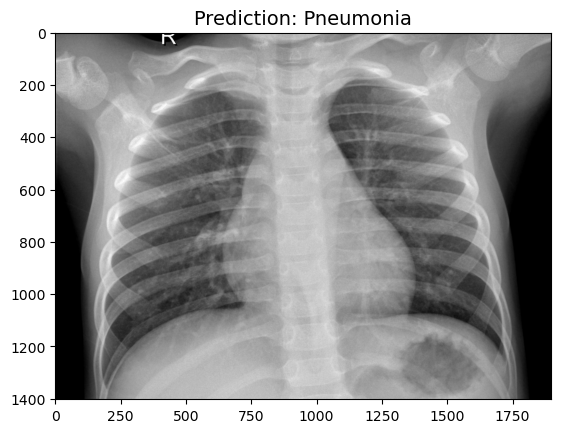

In [23]:
prediction = model.predict(img) >= 0.5
if prediction>=0.5:
    prediction = "Pneumonia"
else:
    prediction = "Normal"
print("Prediction: "+prediction)
plt.imshow(tempimg)
plt.title("Prediction: "+prediction, fontsize=14)

In [24]:
img= cv2.imread(r"C:\Users\AMRIN MULLA\Downloads\chest xray dataset\chest_xray\test\PNEUMONIA\person93_bacteria_454.jpeg")
tempimg = img
img = cv2.resize(img,(300,300))
img = img/255.0
img = img.reshape(1,300,300,3)
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[0.7170568]], dtype=float32)

Here another image is used and the model predicted it as **0.999** which is greater than 0.5.

so it have be Pneumonia image which is predicted below.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: Pneumonia


Text(0.5, 1.0, 'Prediction: Pneumonia')

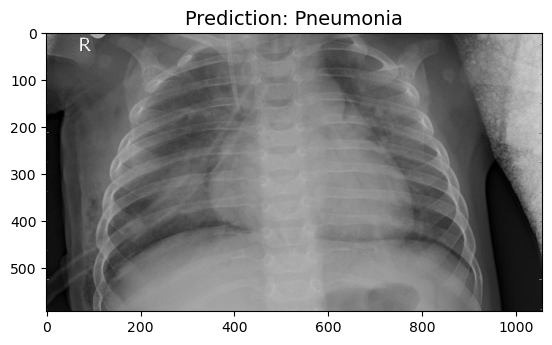

In [25]:
prediction = model.predict(img) >= 0.5
if prediction>=0.5:
    prediction = "Pneumonia"
else:
    prediction = "Normal"
print("Prediction: "+prediction)
plt.imshow(tempimg)
plt.title("Prediction: "+prediction, fontsize=14)

<h2>Conclusion :</h2>

This model can be used in Healthcare industry in the radiological department.

It can be deployed to Xray machines.

This can help radiologist to predict the chest xray images easily and accurately.
